# Análisis exploratorio dataset - Airbnb

## Introducción

In [43]:
import numpy  as np  
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### 1. Carga de datos y división train/test

Para esta exploración de datos, se decide crear dos archivos train/test para la exploración de los datos y construcción del modelo, esto nos permite evitar el data leakage. Adicional se define que lo datos van a estar separados en 70% Train y 30% Test.

In [44]:
# Importamos la librería para dividir el dataset en train y test
from sklearn.model_selection import train_test_split

# Cargamos el dataset completo en un DataFrame de pandas "full_df"
full_df = pd.read_csv("./airbnb-listings-extract.csv", delimiter=';')
train, test = train_test_split(full_df, test_size=0.3, shuffle=True, random_state=0)

# Dimensiones de los datasets de training y test
print('Dimensiones de los datasets:')
print(f'Original 100% de los datos: {full_df.shape}')
print(f'Training 70% de los datos: {train.shape}')
print(f'Test 30% de los datos: {test.shape}')

# Se guardan los datasets de training y test en formato CSV, con el separador ';' y el decimal '.'
train.to_csv('./airbnb_train.csv', sep=';', decimal='.', index=False)
test.to_csv('./airbnb_test.csv', sep=';', decimal='.', index=False)

Dimensiones de los datasets:
Original 100% de los datos: (14780, 89)
Training 70% de los datos: (10346, 89)
Test 30% de los datos: (4434, 89)


### 2. Análisis exploratorio

In [45]:
# Cargamos el dataset de training en un DataFrame de pandas "airbnb_df"
airbnb_df_full = pd.read_csv('./airbnb_train.csv', sep=';', decimal='.')

# Mostramos las primeras 5 filas del dataset de training (la funcion .T nos permite mostrar las filas como columnas)
airbnb_df_full.head(5)

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,2156319,https://www.airbnb.com/rooms/2156319,20170407214119,2017-04-08,GRANT VII Plaza Mayor,NaN,Beautiful and charming apartment recently deco...,Beautiful and charming apartment recently deco...,none,NaN,...,9.0,10.0,9.0,NaN,NaN,strict,40.0,0.24,"40.4154180336,-3.70712273935","Host Has Profile Pic,Host Identity Verified,Is..."
1,3377153,https://www.airbnb.com/rooms/3377153,20170407214119,2017-04-08,Nice flat in Plaza Mayor (lift),"Flat is in the centre town, really close to Pl...",You cannot find a better location to stay in M...,"Flat is in the centre town, really close to Pl...",none,"It´s really cool, with a lot of new business (...",...,10.0,10.0,9.0,NaN,NaN,flexible,1.0,5.61,"40.411131472,-3.7072583983","Host Has Profile Pic,Host Identity Verified,Is..."
2,14800635,https://www.airbnb.com/rooms/14800635,20170407214119,2017-04-08,* ROOM double Barrio Salamanca *,"Private room for two persons has a double bed,...",It is a penthouse located in the salamanca dis...,"Private room for two persons has a double bed,...",none,The District of Salamanca is one of the 21 dis...,...,10.0,10.0,10.0,NaN,NaN,flexible,3.0,5.45,"40.4280496724,-3.6760419089","Host Has Profile Pic,Host Identity Verified,Re..."
3,11185674,https://www.airbnb.com/rooms/11185674,20170407214119,2017-04-08,cheap apartment in Madrid city cent,"Cheap apartment, next to Madrid rio, just four...",NaN,"Cheap apartment, next to Madrid rio, just four...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,flexible,1.0,0.16,"40.3964492726,-3.71409988867","Host Has Profile Pic,Is Location Exact,Require..."
4,18092171,https://www.airbnb.com/rooms/18092171,20170407214119,2017-04-08,"ACOGEDOR APARTAMENTO EN MADRID, CALLE MANZANARES","Acogedor apartamento, para parejas y/o familia.",NaN,"Acogedor apartamento, para parejas y/o familia.",none,NaN,...,NaN,NaN,NaN,NaN,NaN,strict,3.0,NaN,"40.4134467958,-3.71843838152","Host Has Profile Pic,Is Location Exact,Require..."


In [46]:
#Se validan todas las columnas del Dataset, cantidad de nulos y tipo de dato.
airbnb_df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10346 entries, 0 to 10345
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              10346 non-null  int64  
 1   Listing Url                     10346 non-null  object 
 2   Scrape ID                       10346 non-null  int64  
 3   Last Scraped                    10346 non-null  object 
 4   Name                            10345 non-null  object 
 5   Summary                         9922 non-null   object 
 6   Space                           7619 non-null   object 
 7   Description                     10340 non-null  object 
 8   Experiences Offered             10346 non-null  object 
 9   Neighborhood Overview           6397 non-null   object 
 10  Notes                           3960 non-null   object 
 11  Transit                         6327 non-null   object 
 12  Access                          

In [47]:
#Columnas consultadas para evaluar su contenido y determinar si se eliminan

airbnb_df_full[['ID','Neighbourhood','Neighbourhood Cleansed','Neighbourhood Group Cleansed']]

#airbnb_df_full[['ID','Market']]
#airbnb_df_full['Market'].value_counts()

airbnb_df_full[['ID','Smart Location']]
airbnb_df_full['Smart Location'].value_counts()

#airbnb_df_full[['ID','Country Code']]

#airbnb_df_full[['ID','Property Type']]
#airbnb_df_full['Property Type'].value_counts()

#airbnb_df_full[['ID','Room Type']]

#airbnb_df_full[['ID','Accommodates']]
#airbnb_df_full['Accommodates'].value_counts()

#airbnb_df_full[['ID','Square Feet']]
#airbnb_df_full['Square Feet'].value_counts()

#airbnb_df_full[['ID','Calculated host listings count']]
#airbnb_df_full[['ID','Features']]

airbnb_df_full[['ID','Country']]
airbnb_df_full['Country'].value_counts()

Country
Spain             9817
United Kingdom     118
United States      115
France              72
Italy               51
Australia           33
Germany             30
Ireland             23
Austria             22
Netherlands         16
Canada              14
Belgium             14
Denmark             10
Switzerland          4
Greece               3
Hong Kong            2
Cuba                 1
Name: count, dtype: int64

In [48]:
#Extraemos las columnas que consideramos mas relevantes por nombre de la columna
#(sentido común y validando el contenido) a un nuevo df

airbnb_df = airbnb_df_full[['ID', 'Street', 'Neighbourhood', 'Neighbourhood Cleansed',
                             'Neighbourhood Group Cleansed', 'City', 'State', 'Smart Location',
                             'Country Code', 'Country','Property Type','Room Type','Accommodates',
                             'Bathrooms','Bedrooms','Price','Number of Reviews','First Review','Last Review',
                             'Reviews per Month']]

In [49]:
#Exploramos los registros con valor null y se reemplzan manualmente de acuerdo a la 
# información de otras columnas.

airbnb_df[airbnb_df['City'].isna()]
airbnb_df['City'].value_counts()
airbnb_df['City'].fillna('Madrid', inplace=True)
vcity_na = [1736, 1963, 4086, 4549]
airbnb_df.iloc[vcity_na]

airbnb_df[airbnb_df['Country'].isna()]
airbnb_df['Country'].value_counts()
airbnb_df['Country'].fillna('Spain', inplace=True)
airbnb_df[2231:2232]
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10346 entries, 0 to 10345
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10346 non-null  int64  
 1   Street                        10346 non-null  object 
 2   Neighbourhood                 6706 non-null   object 
 3   Neighbourhood Cleansed        10346 non-null  object 
 4   Neighbourhood Group Cleansed  9645 non-null   object 
 5   City                          10346 non-null  object 
 6   State                         10240 non-null  object 
 7   Smart Location                10346 non-null  object 
 8   Country Code                  10346 non-null  object 
 9   Country                       10346 non-null  object 
 10  Property Type                 10346 non-null  object 
 11  Room Type                     10346 non-null  object 
 12  Accommodates                  10346 non-null  int64  
 13  B

In [50]:
#El 95% de los datos corresponden a España, por lo que se determina que el modelo solo funcionaran 
# para España por que los datos de otros paises no son suficientes, solo nos quedamos con estos registros

airbnb_df = airbnb_df[airbnb_df['Country'] == 'Spain']
print(f'Nuevo dataset: {airbnb_df.shape}')

Nuevo dataset: (9818, 20)


In [51]:
#Validamos los campos numericos con nulos e imputamos los datos.
airbnb_df['Bathrooms'].value_counts()
airbnb_df['Bathrooms'].fillna(airbnb_df['Bathrooms'].mode()[0], inplace=True)

airbnb_df['Bedrooms'].value_counts()
airbnb_df['Bedrooms'].fillna(airbnb_df['Bedrooms'].mode()[0], inplace=True)

airbnb_df['Price'].fillna(airbnb_df['Price'].mode()[0], inplace=True)

airbnb_df.isnull().any()

ID                              False
Street                          False
Neighbourhood                    True
Neighbourhood Cleansed          False
Neighbourhood Group Cleansed     True
City                            False
State                            True
Smart Location                  False
Country Code                    False
Country                         False
Property Type                   False
Room Type                       False
Accommodates                    False
Bathrooms                       False
Bedrooms                        False
Price                           False
Number of Reviews               False
First Review                     True
Last Review                      True
Reviews per Month                True
dtype: bool

In [52]:
# Se eliminan las columnas que no es posible imputar
airbnb_df = airbnb_df.drop(['ID','Neighbourhood','Neighbourhood Group Cleansed','State','Country Code','Country','First Review','Last Review','Reviews per Month'], axis=1)
airbnb_df.isnull().any()

Street                    False
Neighbourhood Cleansed    False
City                      False
Smart Location            False
Property Type             False
Room Type                 False
Accommodates              False
Bathrooms                 False
Bedrooms                  False
Price                     False
Number of Reviews         False
dtype: bool

In [54]:
#Reemplazo de nombres y verificación de la información
airbnb_df.columns = ['Street', 'Neighbourhood', 'City', 'Smart_Location',
                     'Property_Type', 'Room_Type', 'Accommodates',
                     'Bathrooms', 'Bedrooms', 'Price', 'Total_Reviews']
print('datset: airbnb_df')
airbnb_df.info()

datset: airbnb_df
<class 'pandas.core.frame.DataFrame'>
Index: 9818 entries, 0 to 10345
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Street          9818 non-null   object 
 1   Neighbourhood   9818 non-null   object 
 2   City            9818 non-null   object 
 3   Smart_Location  9818 non-null   object 
 4   Property_Type   9818 non-null   object 
 5   Room_Type       9818 non-null   object 
 6   Accommodates    9818 non-null   int64  
 7   Bathrooms       9818 non-null   float64
 8   Bedrooms        9818 non-null   float64
 9   Price           9818 non-null   float64
 10  Total_Reviews   9818 non-null   int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 920.4+ KB


In [57]:
#Aplicamos el enconder para convertir todas las variables de tipo object
#El TargetEncoder se puede utilizar pero es necesario hacer la categorización con la variable objetivo,
# que buscando un información genera Data Lakage y Overfitting, por lo que la opción es utilizar OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
airbnb_df[['Street']] = encoder.fit_transform(airbnb_df[['Street']])
airbnb_df[['Neighbourhood']] = encoder.fit_transform(airbnb_df[['Neighbourhood']])
airbnb_df[['City']] = encoder.fit_transform(airbnb_df[['City']])
airbnb_df[['Smart_Location']] = encoder.fit_transform(airbnb_df[['Smart_Location']])
airbnb_df[['Property_Type']] = encoder.fit_transform(airbnb_df[['Property_Type']])
airbnb_df[['Room_Type']] = encoder.fit_transform(airbnb_df[['Room_Type']])
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9818 entries, 0 to 10345
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Street          9818 non-null   float64
 1   Neighbourhood   9818 non-null   float64
 2   City            9818 non-null   float64
 3   Smart_Location  9818 non-null   float64
 4   Property_Type   9818 non-null   float64
 5   Room_Type       9818 non-null   float64
 6   Accommodates    9818 non-null   int64  
 7   Bathrooms       9818 non-null   float64
 8   Bedrooms        9818 non-null   float64
 9   Price           9818 non-null   float64
 10  Total_Reviews   9818 non-null   int64  
dtypes: float64(9), int64(2)
memory usage: 920.4 KB


### 3. Visualización de variables

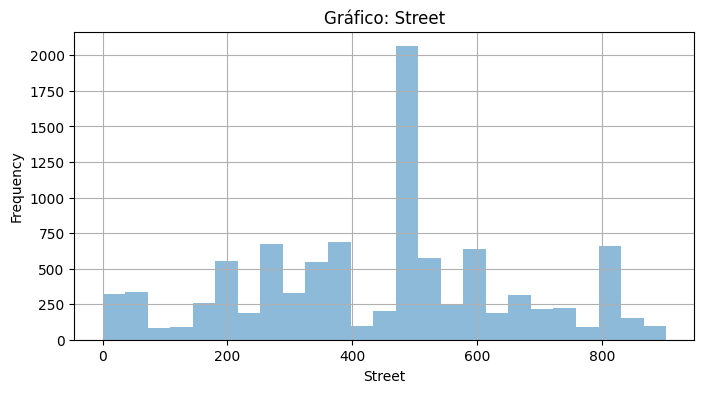

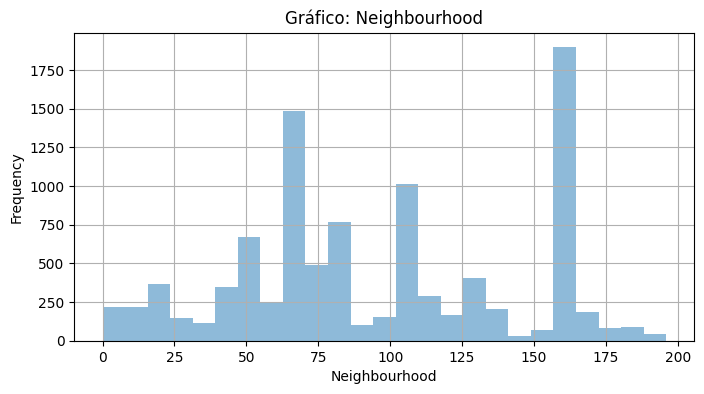

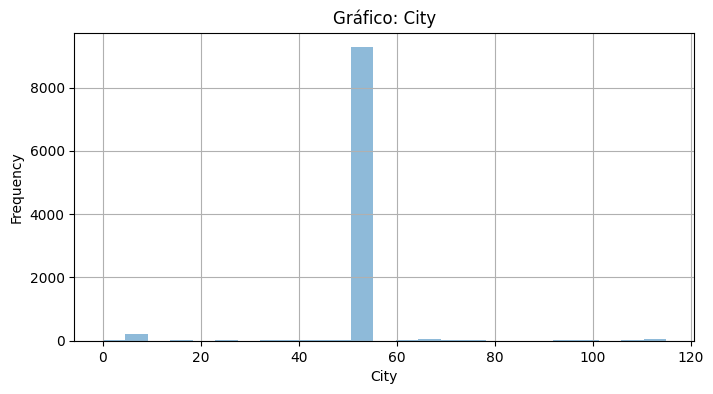

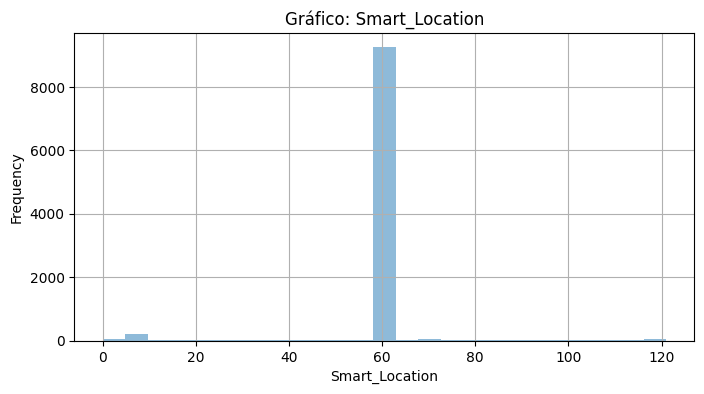

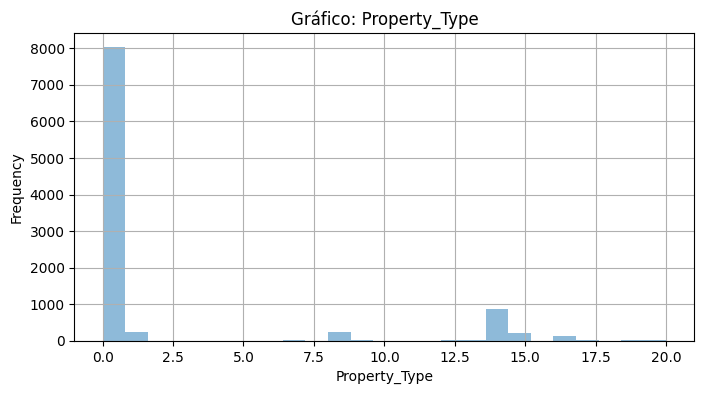

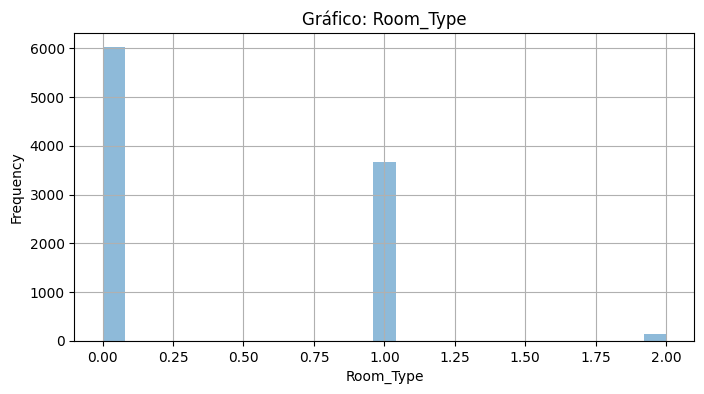

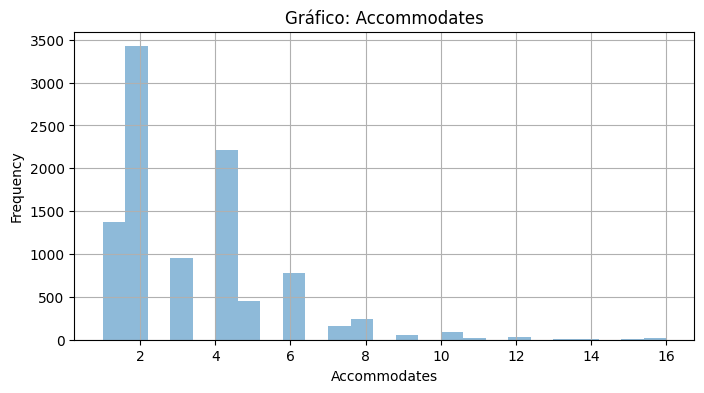

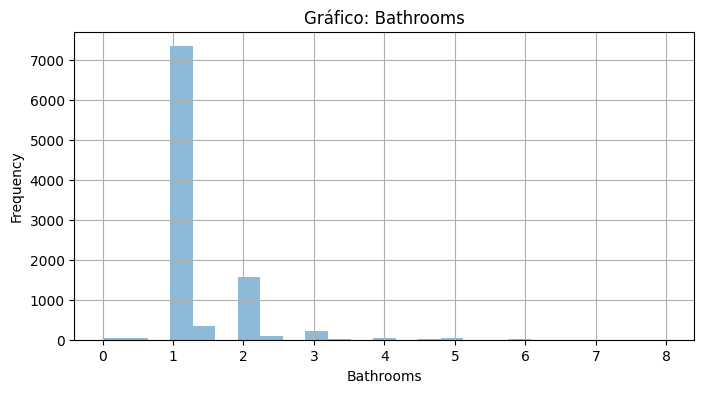

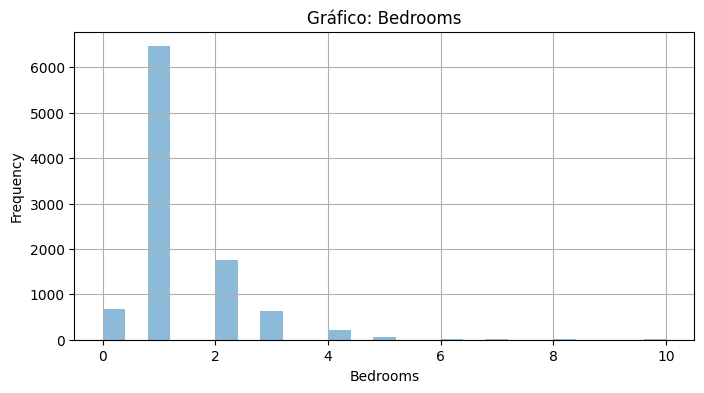

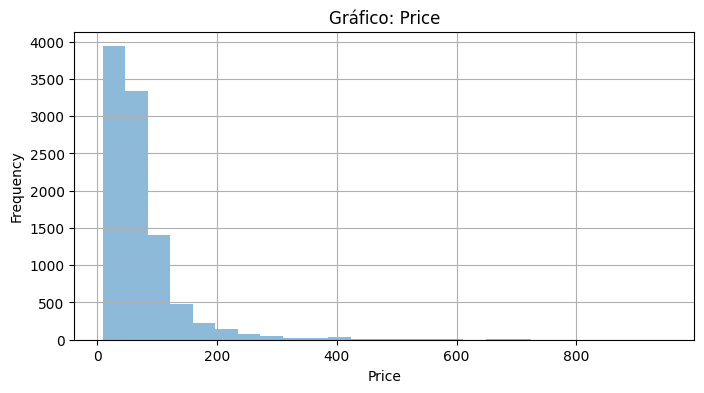

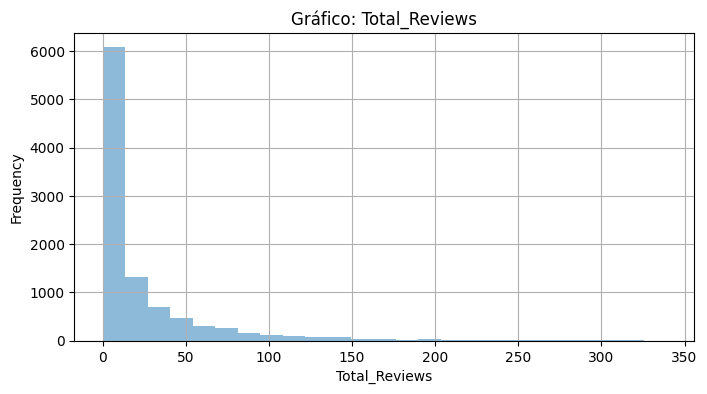

In [58]:
#Graficamos en un histograma
for c in airbnb_df.columns:
    plt.figure(figsize=(8, 4))
    airbnb_df[c].plot.hist(alpha=0.5, bins=25, grid = True)
    plt.title(f'Gráfico: {c}')
    plt.xlabel(c)

plt.show()

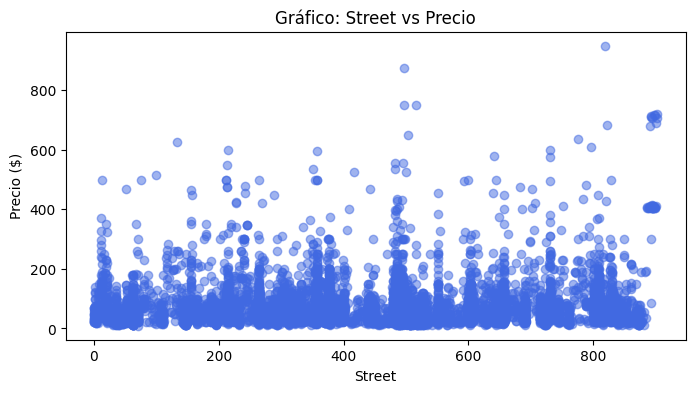

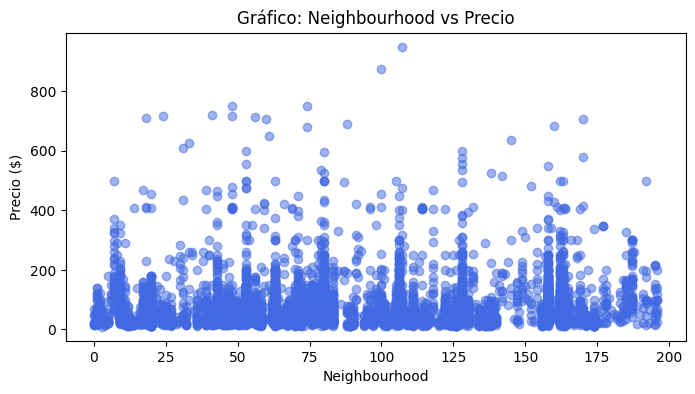

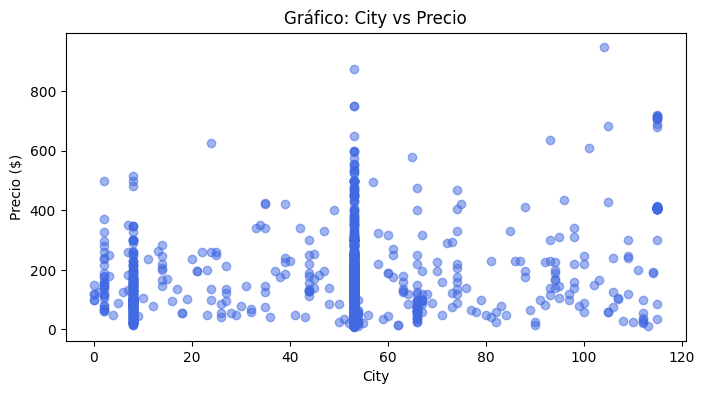

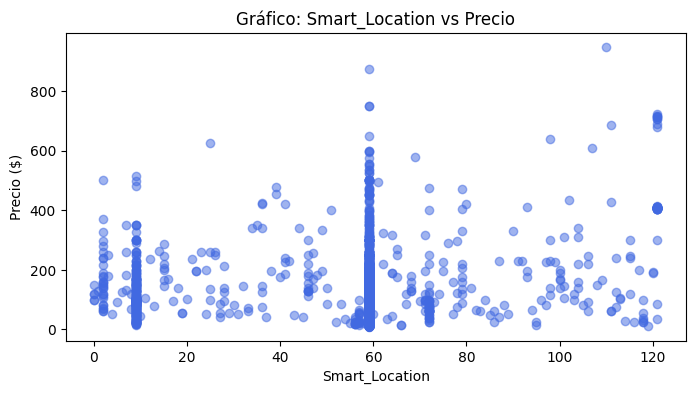

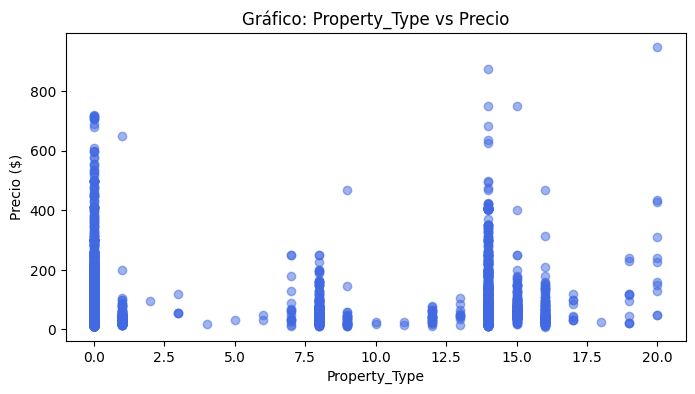

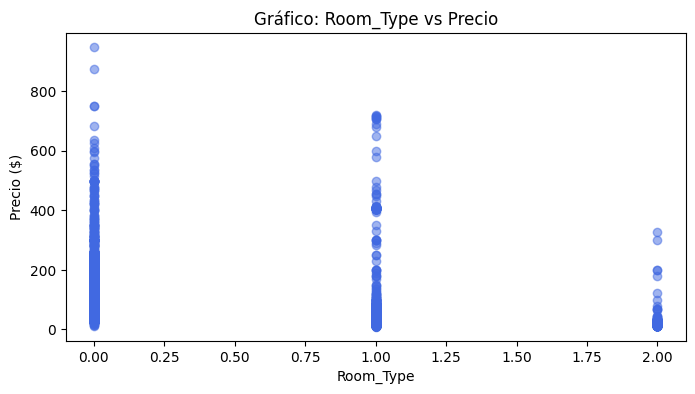

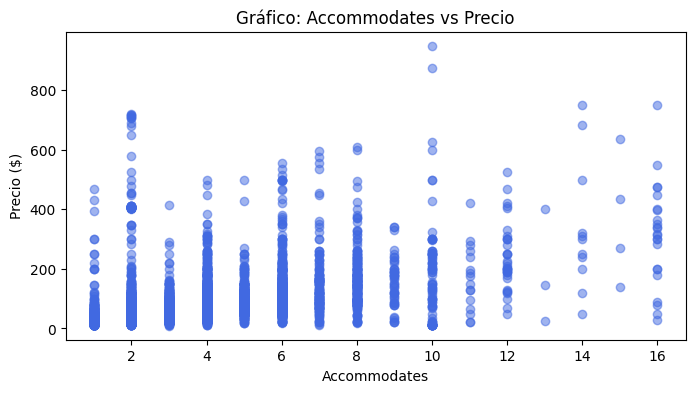

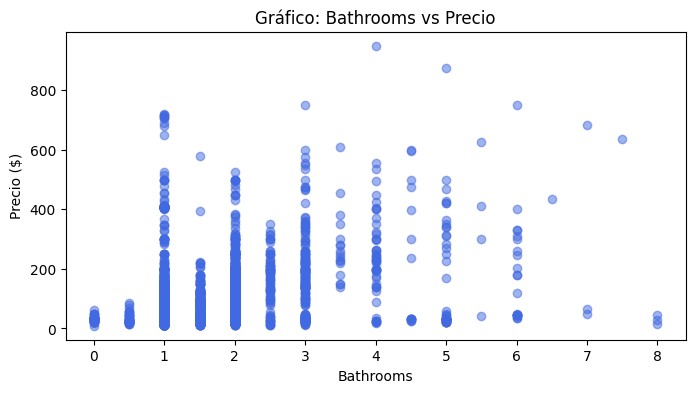

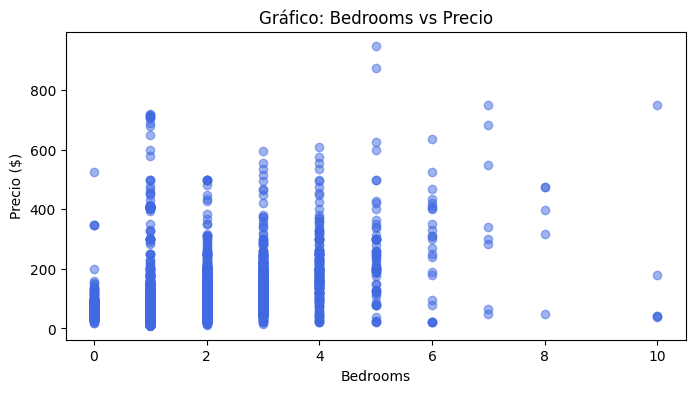

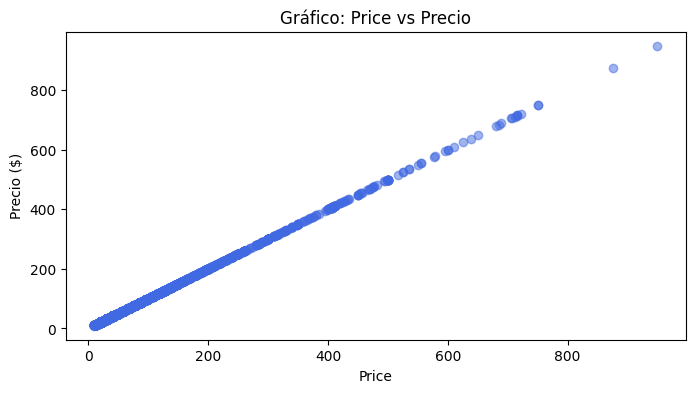

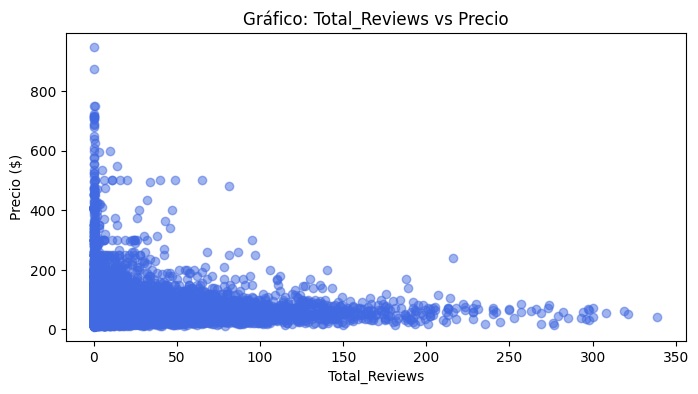

In [59]:
#Graficamos en un histograma
for c in airbnb_df.columns:
    plt.figure(figsize=(8, 4))
    plt.scatter(airbnb_df[c], airbnb_df['Price'], alpha=0.5, color='royalblue')
    plt.title(f'Gráfico: {c} vs Precio')
    plt.xlabel(c)
    plt.ylabel('Precio ($)')

plt.show()

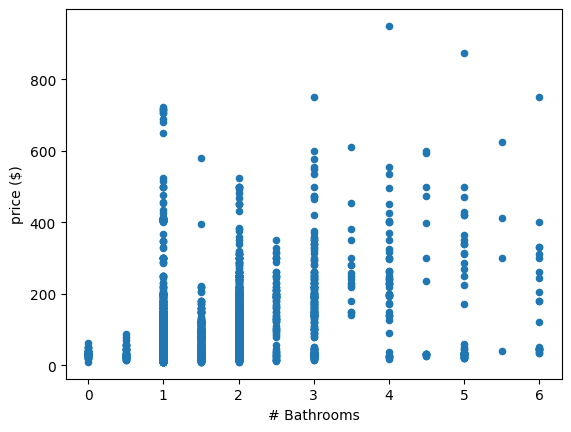

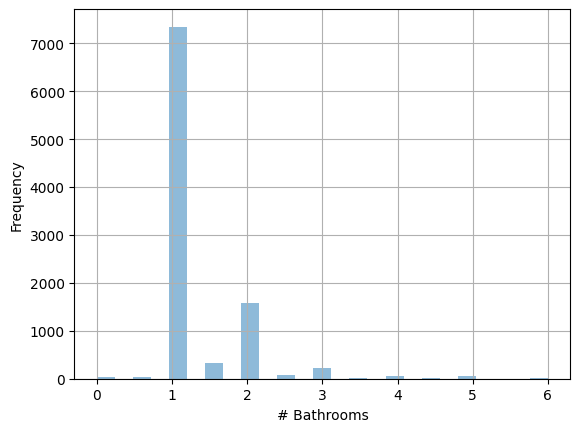

In [60]:
#Limpiar Outliers Bathrooms
airbnb_df_no_outliers_bathrooms = airbnb_df[airbnb_df['Bathrooms'] <= 6]

airbnb_df_no_outliers_bathrooms.plot(kind = 'scatter',x='Bathrooms',y = 'Price')
plt.xlabel('# Bathrooms')
plt.ylabel('price ($)')
plt.show()

airbnb_df_no_outliers_bathrooms['Bathrooms'].plot.hist(alpha=0.5, bins=25, grid = True)
plt.xlabel('# Bathrooms')
plt.show()

In [61]:
print(f'Outliers Bathrooms')
print(    
    f'Original: {airbnb_df.shape[0]} // '
    f'Modificado: {airbnb_df_no_outliers_bathrooms.shape[0]}\nDiferencia: {airbnb_df.shape[0] - airbnb_df_no_outliers_bathrooms.shape[0]}'
)
print(f'Variación: {((airbnb_df.shape[0] - airbnb_df_no_outliers_bathrooms.shape[0])/airbnb_df.shape[0])*100:2f}%')

Outliers Bathrooms
Original: 9818 // Modificado: 9810
Diferencia: 8
Variación: 0.081483%


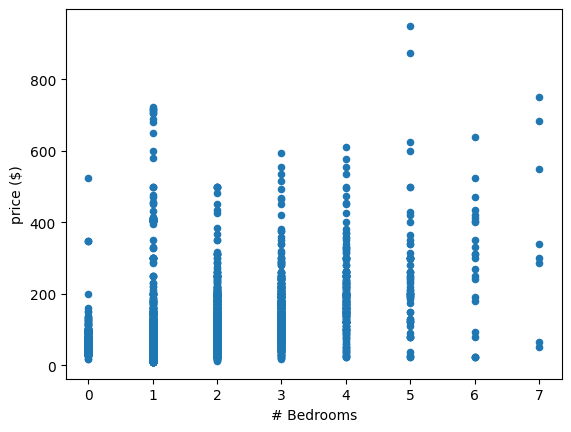

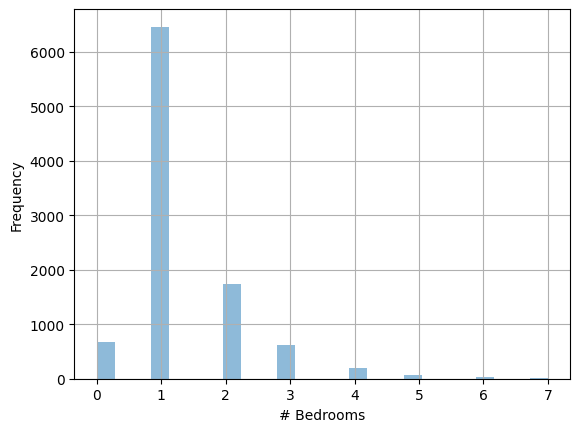

In [62]:
#Limpiar Outliers Bedrooms
airbnb_df_no_outliers_bedrooms = airbnb_df[airbnb_df['Bedrooms'] <= 7]

airbnb_df_no_outliers_bedrooms.plot(kind = 'scatter',x='Bedrooms',y = 'Price')
plt.xlabel('# Bedrooms')
plt.ylabel('price ($)')
plt.show()

airbnb_df_no_outliers_bedrooms['Bedrooms'].plot.hist(alpha=0.5, bins=25, grid = True)
plt.xlabel('# Bedrooms')
plt.show()

In [63]:
print(f'Outliers Bedrooms')
print(    
    f'Original: {airbnb_df.shape[0]} // '
    f'Modificado: {airbnb_df_no_outliers_bedrooms.shape[0]}\nDiferencia: {airbnb_df.shape[0] - airbnb_df_no_outliers_bedrooms.shape[0]}'
)
print(f'Variación: {((airbnb_df.shape[0] - airbnb_df_no_outliers_bedrooms.shape[0])/airbnb_df.shape[0])*100:2f}%')

Outliers Bedrooms
Original: 9818 // Modificado: 9808
Diferencia: 10
Variación: 0.101854%


In [64]:
### Se actualiza dataset
airbnb_df = airbnb_df[airbnb_df['Bathrooms'] <= 6]
airbnb_df = airbnb_df[airbnb_df['Bedrooms'] <= 7]
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9801 entries, 0 to 10345
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Street          9801 non-null   float64
 1   Neighbourhood   9801 non-null   float64
 2   City            9801 non-null   float64
 3   Smart_Location  9801 non-null   float64
 4   Property_Type   9801 non-null   float64
 5   Room_Type       9801 non-null   float64
 6   Accommodates    9801 non-null   int64  
 7   Bathrooms       9801 non-null   float64
 8   Bedrooms        9801 non-null   float64
 9   Price           9801 non-null   float64
 10  Total_Reviews   9801 non-null   int64  
dtypes: float64(9), int64(2)
memory usage: 918.8 KB


In [65]:
#Matriz de correlación
airbnb_df.corr()

,Street,Neighbourhood,City,Smart_Location,Property_Type,Room_Type,Accommodates,Bathrooms,Bedrooms,Price,Total_Reviews
Street,1.000000,0.493833,0.245289,0.241742,-0.006667,-0.013544,0.015553,0.034787,-0.001987,0.080689,0.013142
Neighbourhood,0.493833,1.000000,-0.101881,-0.104981,-0.049719,-0.072087,0.064321,0.016934,0.025174,0.057911,0.060477
City,0.245289,-0.101881,1.000000,0.997791,0.052964,0.081492,-0.071114,-0.010966,-0.056457,0.081943,-0.007971
Smart_Location,0.241742,-0.104981,0.997791,1.000000,0.040985,0.083905,-0.082515,-0.023687,-0.071121,0.055537,-0.002979
Property_Type,-0.006667,-0.049719,0.052964,0.040985,1.000000,0.080759,0.039678,0.128439,0.110245,0.082259,-0.063977
Room_Type,-0.013544,-0.072087,0.081492,0.083905,0.080759,1.000000,-0.500784,-0.021699,-0.270697,-0.375396,-0.128586
Accommodates,0.015553,0.064321,-0.071114,-0.082515,0.039678,-0.500784,1.000000,0.406937,0.727764,0.531292,0.061386
Bathrooms,0.034787,0.016934,-0.010966,-0.023687,0.128439,-0.021699,0.406937,1.000000,0.499292,0.376398,-0.077381
Bedrooms,-0.001987,0.025174,-0.056457,-0.071121,0.110245,-0.270697,0.727764,0.499292,1.000000,0.500239,-0.048031
Price,0.080689,0.057911,0.081943,0.055537,0.082259,-0.375396,0.531292,0.376398,0.500239,1.000000,-0.067268


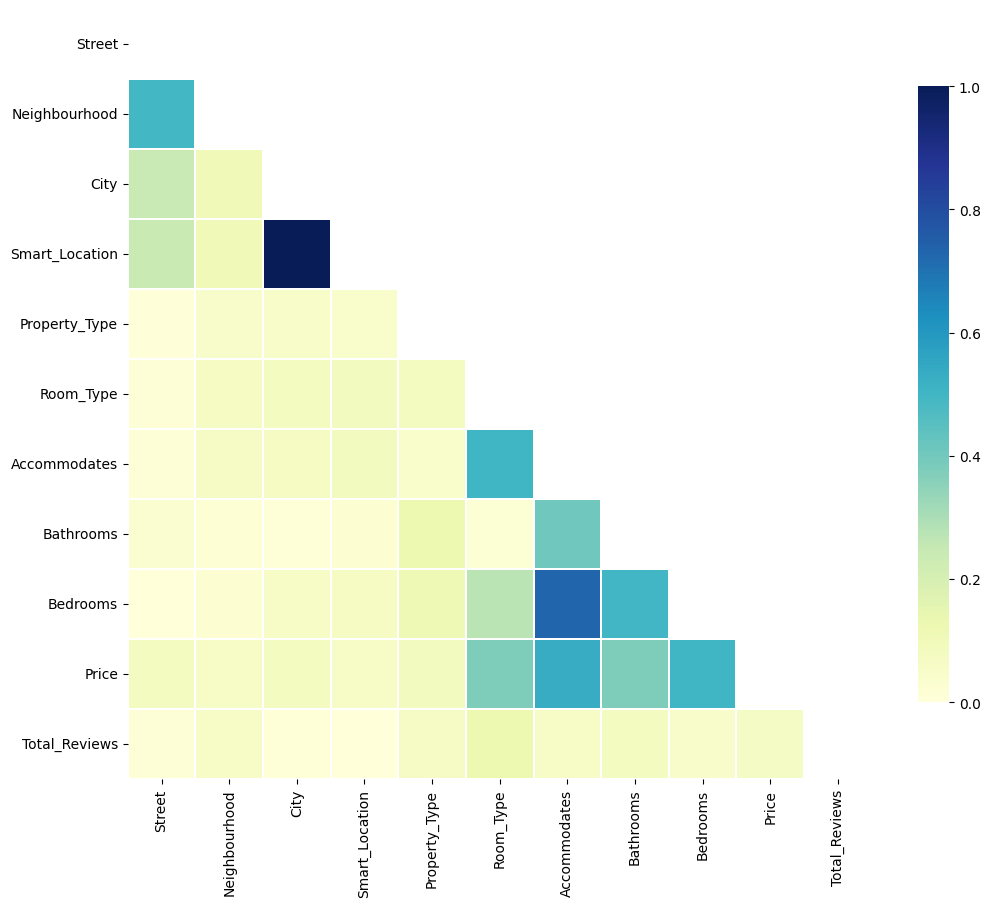

In [66]:
#Gráfica de correlación
import seaborn as sns

# Compute the correlation matrix
corr = np.abs(airbnb_df.corr())

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(12, 10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,vmin = 0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8})

plt.show()

In [67]:
#Se elimina la columna que tienen la misma correlación por lo que seria redundante en nuestro modelo
airbnb_df = airbnb_df.drop(['Smart_Location'], axis=1)
#airbnb_df.info()

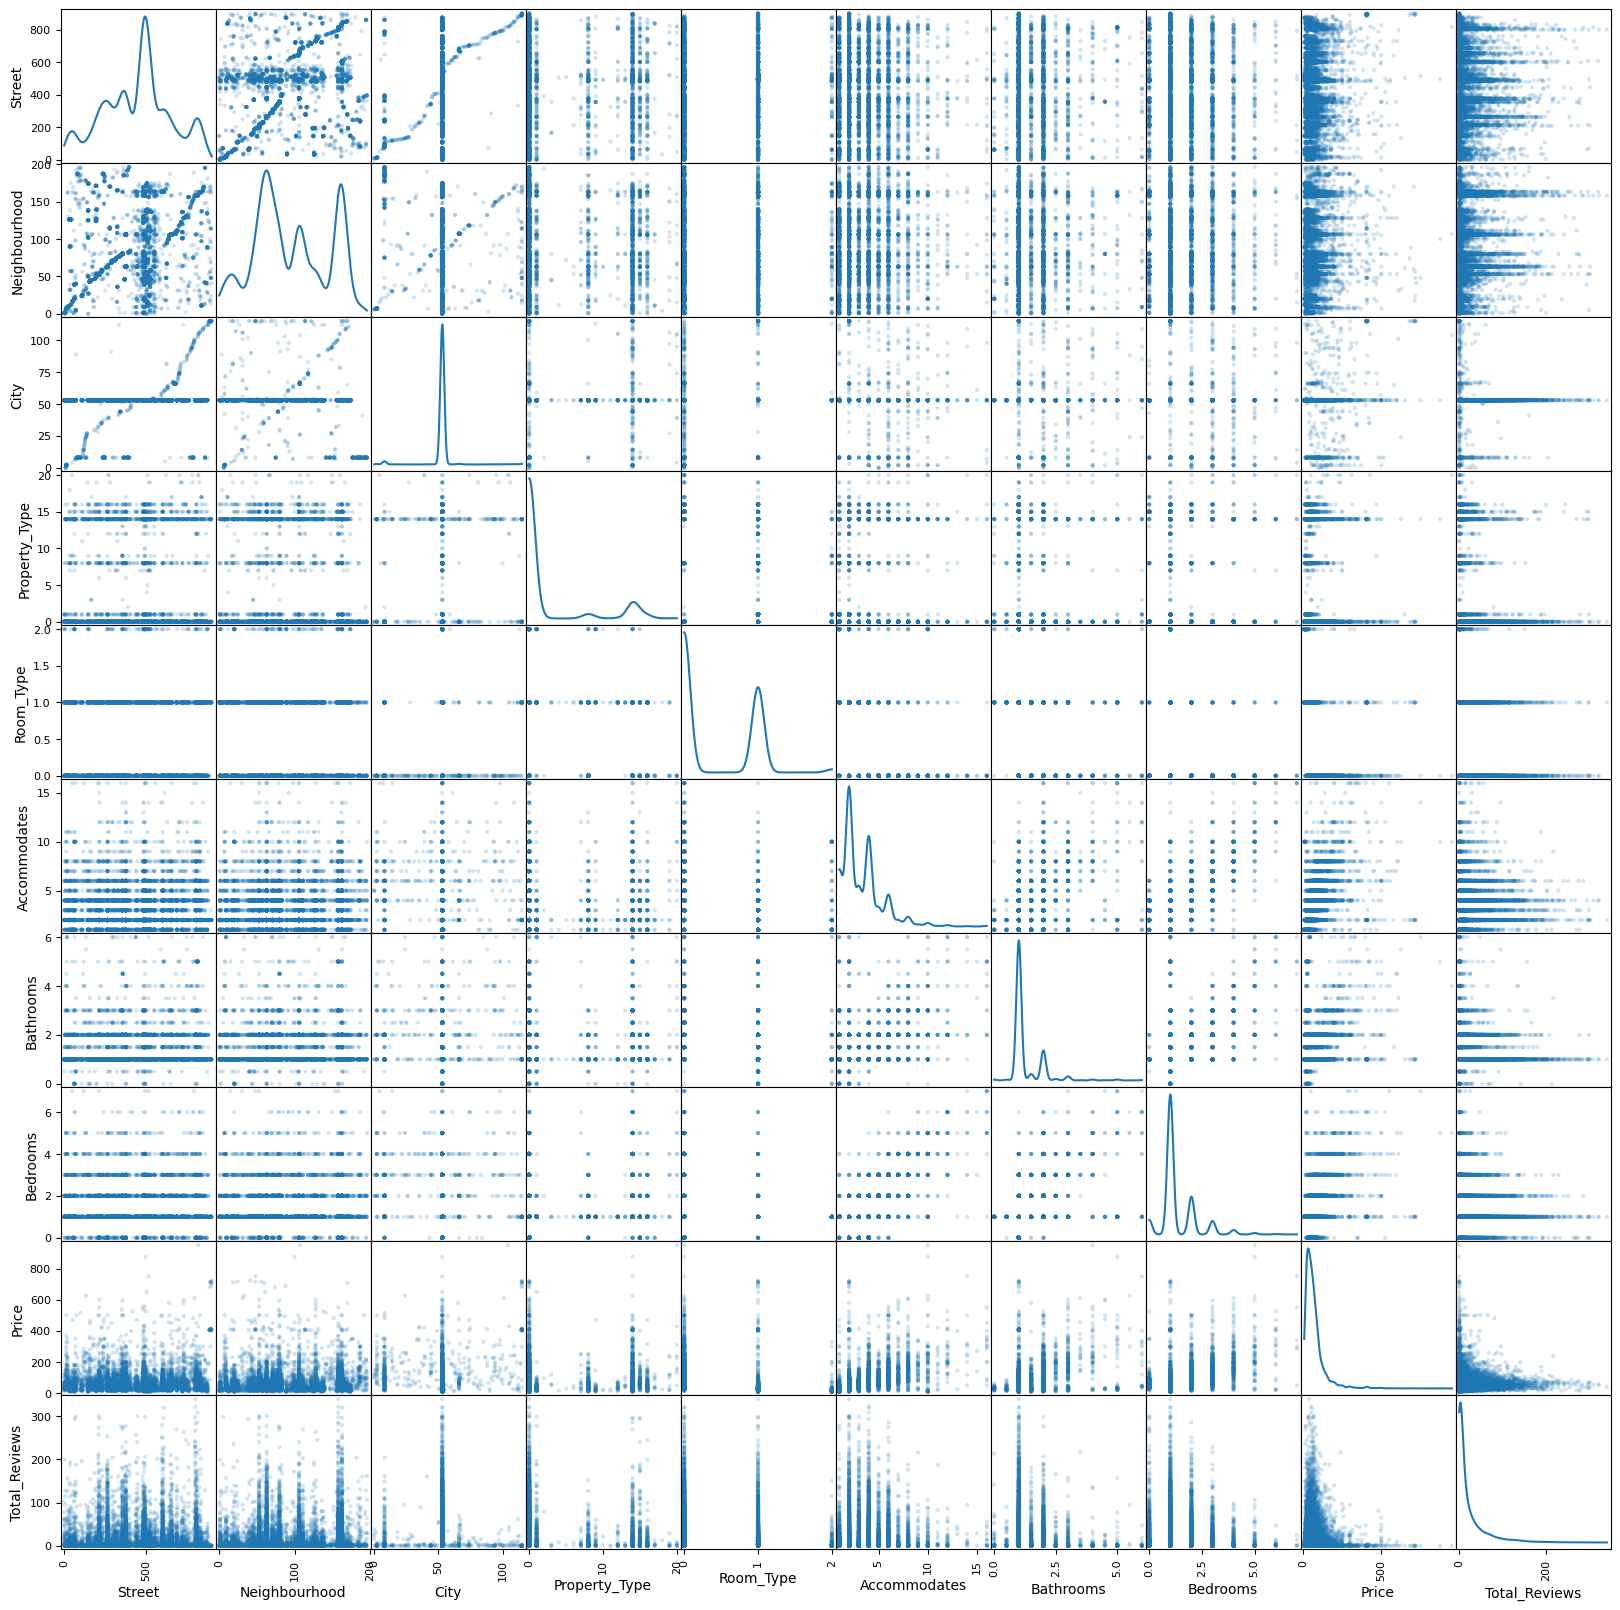

In [68]:
pd.plotting.scatter_matrix(airbnb_df, alpha=0.2, figsize=(20, 20), diagonal = 'kde')
plt.show()

## 4. Modelado, cross-validation y estudio de resultados en train y test
### Proceso en el dataset Train

In [69]:
# Carga de datos
airbnb_data_full = pd.read_csv('./airbnb_train.csv', sep=';', decimal='.')

# Imputamos el pais y filtrmos
airbnb_data_full['Country'].fillna('Spain', inplace=True) # Omitir en test
airbnb_data_full = airbnb_data_full[airbnb_data_full['Country'] == 'Spain']

# Imputación
airbnb_data_full['City'].fillna('Madrid', inplace=True) # Omitir en test
airbnb_data_full['Bathrooms'].fillna(airbnb_data_full['Bathrooms'].mode()[0], inplace=True)
airbnb_data_full['Bedrooms'].fillna(airbnb_data_full['Bedrooms'].mode()[0], inplace=True)
airbnb_data_full['Price'].fillna(airbnb_data_full['Price'].mode()[0], inplace=True)

# Extraemos columnas que nos importan
airbnb_data = airbnb_data_full[['Price', 'Street', 'Neighbourhood Cleansed', 'City', 'Property Type',
                              'Room Type','Accommodates', 'Bathrooms', 'Bedrooms', 'Number of Reviews']]

# Renombramos columnas
airbnb_data.columns = ['Price', 'Street', 'Neighbourhood', 'City',  'Property_Type',
                       'Room_Type', 'Accommodates', 'Bathrooms', 'Bedrooms', 'Total_Reviews']

# Aplicamos el encoder
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
categorical_cols = [
    'Street', 'Neighbourhood', 'City', 'Property_Type', 'Room_Type'
]
airbnb_data[categorical_cols] = encoder.fit_transform(airbnb_data[categorical_cols])

# Eliminamos outliers en bedrooms
airbnb_data = airbnb_data[airbnb_data['Bathrooms'] <= 6]
airbnb_data = airbnb_data[airbnb_data['Bedrooms'] <= 7]

# Verificamos el dataset
airbnb_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9801 entries, 0 to 10345
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price          9801 non-null   float64
 1   Street         9801 non-null   float64
 2   Neighbourhood  9801 non-null   float64
 3   City           9801 non-null   float64
 4   Property_Type  9801 non-null   float64
 5   Room_Type      9801 non-null   float64
 6   Accommodates   9801 non-null   int64  
 7   Bathrooms      9801 non-null   float64
 8   Bedrooms       9801 non-null   float64
 9   Total_Reviews  9801 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 842.3 KB


### Proceso en el dataset Test

In [70]:
# Carga de datos
airbnb_data_test_full = pd.read_csv('./airbnb_test.csv', sep=';', decimal='.')

# Imputamos el pais y filtrmos
airbnb_data_test_full = airbnb_data_test_full[airbnb_data_test_full['Country'] == 'Spain']

# Imputación
airbnb_data_test_full['Bathrooms'].fillna(airbnb_data_test_full['Bathrooms'].mode()[0], inplace=True)
airbnb_data_test_full['Bedrooms'].fillna(airbnb_data_test_full['Bedrooms'].mode()[0], inplace=True)
airbnb_data_test_full['Price'].fillna(airbnb_data_test_full['Price'].mode()[0], inplace=True)

# Extraemos columnas que nos importan
airbnb_data_test = airbnb_data_test_full[['Price', 'Street', 'Neighbourhood Cleansed', 'City', 'Property Type',
                                          'Room Type','Accommodates', 'Bathrooms', 'Bedrooms', 'Number of Reviews']]

# Renombramos columnas
airbnb_data_test.columns = ['Price', 'Street', 'Neighbourhood', 'City',  'Property_Type',
                            'Room_Type', 'Accommodates', 'Bathrooms', 'Bedrooms', 'Total_Reviews']

# Aplicamos el encoder
airbnb_data_test[categorical_cols] = encoder.fit_transform(airbnb_data_test[categorical_cols])

# Diligenciamos los null
airbnb_data_test['City'].fillna(airbnb_data_test['City'].mode()[0], inplace=True)

# Eliminamos outliers en bedrooms
airbnb_data_test = airbnb_data_test[airbnb_data_test['Bathrooms'] <= 6]
airbnb_data_test = airbnb_data_test[airbnb_data_test['Bedrooms'] <= 7]

# Verificamos el dataset
airbnb_data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4176 entries, 0 to 4433
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price          4176 non-null   float64
 1   Street         4176 non-null   float64
 2   Neighbourhood  4176 non-null   float64
 3   City           4176 non-null   float64
 4   Property_Type  4176 non-null   float64
 5   Room_Type      4176 non-null   float64
 6   Accommodates   4176 non-null   int64  
 7   Bathrooms      4176 non-null   float64
 8   Bedrooms       4176 non-null   float64
 9   Total_Reviews  4176 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 358.9 KB


In [71]:
# Dataset de train
data_train = airbnb_data.values
X_train_raw = data_train[:,1:]      # nos quedamos con el resto
y_train = data_train[:,0:1]     # nos quedamos con la 1ª columna, price

# Dataset de test
data_test = airbnb_data_test.values
X_test_raw = data_test[:,1:]      # nos quedamos con el resto
y_test = data_test[:,0:1]     # nos quedamos con la 1ª columna, price

In [72]:
from sklearn import preprocessing

# Escalamos los datos y se normalizan
scaler = preprocessing.StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)

# recordad que esta normalización/escalado la realizo con el scaler anterior, basado en los datos de training!
X_test = scaler.transform(X_test_raw)

# Visualización de los datos
print('Datos entrenamiento: ', X_train.shape)
print('Datos test: ', X_test.shape)

Datos entrenamiento:  (9801, 9)
Datos test:  (4176, 9)


### 4.1 Implementación de Lasso

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................alpha=0.37926901907322497; total time=   0.0s
[CV] END ..........................alpha=0.37926901907322497; total time=   0.0s
[CV] END ..........................alpha=0.37926901907322497; total time=   0.0s
[CV] END ............................alpha=1.438449888287663; total time=   0.0s
[CV] END ............................alpha=1.438449888287663; total time=   0.0s
[CV] END ............................alpha=1.438449888287663; total time=   0.0s
[CV] END .............................alpha=5.45559478116852; total time=   0.0s
[CV] END .............................alpha=5.45559478116852; total time=   0.0s
[CV] END .............................alpha=5.45

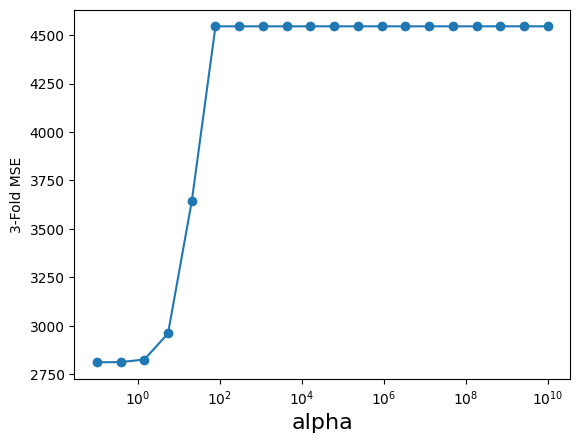

In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

alpha_vector = np.logspace(-1,10,20)
param_grid = {'alpha': alpha_vector }
grid = GridSearchCV(Lasso(), scoring= 'neg_mean_squared_error', param_grid=param_grid, cv = 3, verbose=2)
grid.fit(X_train, y_train)
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

#-1 porque es negado
scores = -1*np.array(grid.cv_results_['mean_test_score'])
plt.semilogx(alpha_vector,scores,'-o')
plt.xlabel('alpha',fontsize=16)
plt.ylabel('3-Fold MSE')
plt.show()

In [74]:
# 
from sklearn.metrics import mean_squared_error

alpha_optimo = grid.best_params_['alpha']
lasso = Lasso(alpha = alpha_optimo).fit(X_train, y_train)

ytrainLasso = lasso.predict(X_train)
ytestLasso  = lasso.predict(X_test)
mseTrainModelLasso = mean_squared_error(y_train, ytrainLasso)
mseTestModelLasso = mean_squared_error(y_test, ytestLasso)

print('MSE Modelo Lasso (train): %0.3g' % mseTrainModelLasso)
print('MSE Modelo Lasso (test) : %0.3g' % mseTestModelLasso)

print('RMSE Modelo Lasso (train): %0.3g' % np.sqrt(mseTrainModelLasso))
print('RMSE Modelo Lasso (test) : %0.3g' % np.sqrt(mseTestModelLasso))

feature_names = airbnb_data.columns[1:] # es igual en train y en test

w = lasso.coef_
for f,wi in zip(feature_names,w):
    print(f,wi)

MSE Modelo Lasso (train): 2.79e+03
MSE Modelo Lasso (test) : 2.58e+03
RMSE Modelo Lasso (train): 52.8
RMSE Modelo Lasso (test) : 50.8
Street 1.8100284746698216
Neighbourhood 1.6247546478196315
City 8.125829387505599
Property_Type 2.498115435852801
Room_Type -15.753646532854443
Accommodates 14.308172369774065
Bathrooms 11.923824199847532
Bedrooms 12.862538030309475
Total_Reviews -5.69550773562406


### 4.2 Implementación de Random Forest

Fitting 3 folds for each of 14 candidates, totalling 42 fits
[CV] END ........................................max_depth=1; total time=   0.3s
[CV] END ........................................max_depth=1; total time=   0.2s
[CV] END ........................................max_depth=1; total time=   0.2s
[CV] END ........................................max_depth=2; total time=   0.3s
[CV] END ........................................max_depth=2; total time=   0.3s
[CV] END ........................................max_depth=2; total time=   0.3s
[CV] END ........................................max_depth=3; total time=   0.4s
[CV] END ........................................max_depth=3; total time=   0.4s
[CV] END ........................................max_depth=3; total time=   0.4s
[CV] END ........................................max_depth=4; total time=   0.4s
[CV] END ........................................max_depth=4; total time=   0.4s
[CV] END .......................................

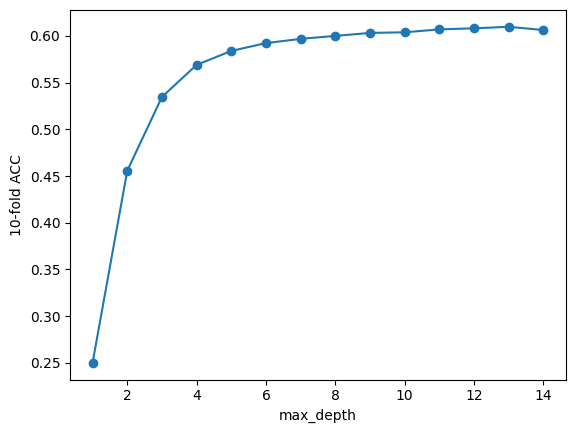

In [75]:
from sklearn.ensemble import RandomForestRegressor

maxDepth = range(1,15)
tuned_parameters = {'max_depth': maxDepth}

grid = GridSearchCV(RandomForestRegressor(random_state=0, n_estimators=200, max_features='sqrt'), param_grid=tuned_parameters,cv=3, verbose=2)
grid.fit(X_train, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth')
plt.ylabel('10-fold ACC')

plt.show()

In [76]:
maxDepthOptimo = grid.best_params_['max_depth']
randomForest = RandomForestRegressor(max_depth=maxDepthOptimo,n_estimators=200,max_features='sqrt').fit(X_train,y_train)

print("Train: ",randomForest.score(X_train,y_train))
print("Test: ",randomForest.score(X_test,y_test))

Train:  0.8362642498803756
Test:  0.4945679831773465


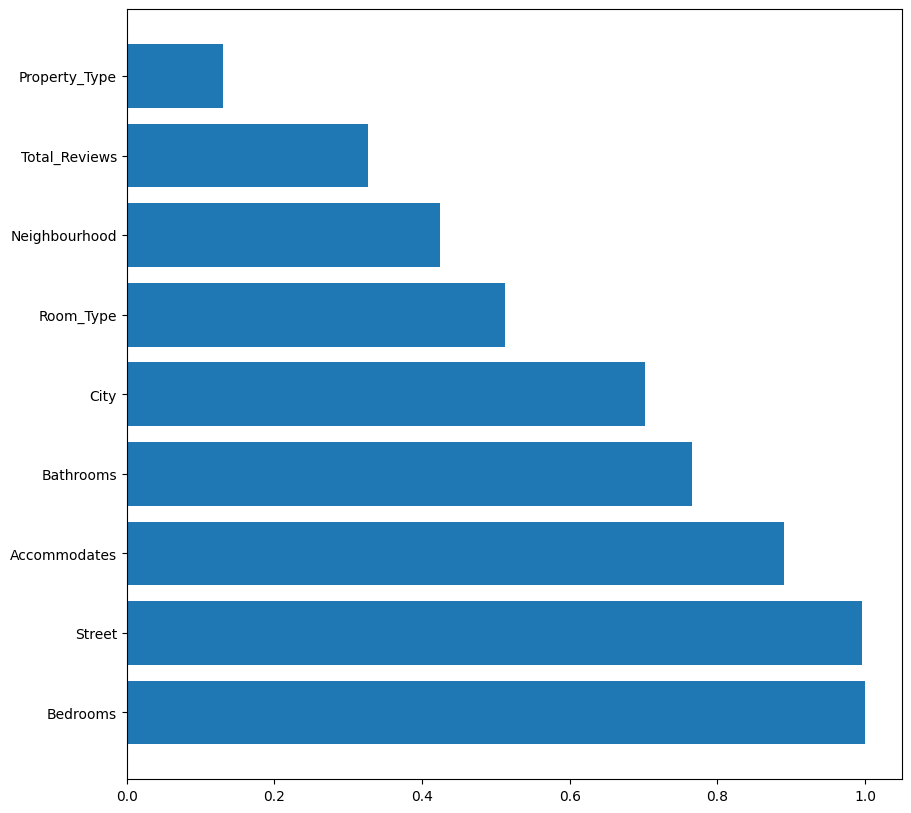

In [77]:
importances = randomForest.feature_importances_
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),feature_names[indices])
plt.show()

### 4.3 Implementación de Baggin regressor

Fitting 3 folds for each of 14 candidates, totalling 42 fits
[CV] END .............................estimator__max_depth=1; total time=   0.5s
[CV] END .............................estimator__max_depth=1; total time=   0.5s
[CV] END .............................estimator__max_depth=1; total time=   0.5s
[CV] END .............................estimator__max_depth=2; total time=   0.6s
[CV] END .............................estimator__max_depth=2; total time=   0.6s
[CV] END .............................estimator__max_depth=2; total time=   0.6s
[CV] END .............................estimator__max_depth=3; total time=   0.8s
[CV] END .............................estimator__max_depth=3; total time=   0.8s
[CV] END .............................estimator__max_depth=3; total time=   0.8s
[CV] END .............................estimator__max_depth=4; total time=   0.9s
[CV] END .............................estimator__max_depth=4; total time=   1.0s
[CV] END .............................estimator_

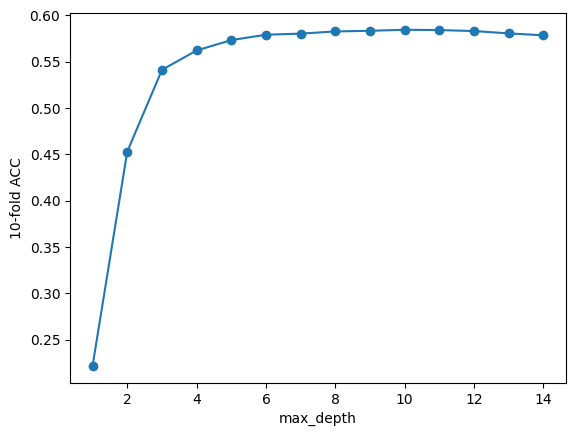

In [78]:
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# ... código aquí: GridSearch
maxDepth = range(1,15)
tuned_parameters = {'estimator__max_depth': maxDepth}

grid = GridSearchCV(BaggingRegressor(estimator=DecisionTreeRegressor(), random_state=0, n_estimators=200), param_grid=tuned_parameters,cv=3, verbose=2)
grid.fit(X_train, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth')
plt.ylabel('10-fold ACC')

plt.show()

In [79]:
maxDepthOptimo = grid.best_params_['estimator__max_depth']
baggingRegressor = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=maxDepthOptimo),n_estimators=200).fit(X_train,y_train)

print("Train: ", baggingRegressor.score(X_train, y_train))
print("Test: ", baggingRegressor.score(X_test, y_test))

Train:  0.7846359195100014
Test:  0.5060153056287833


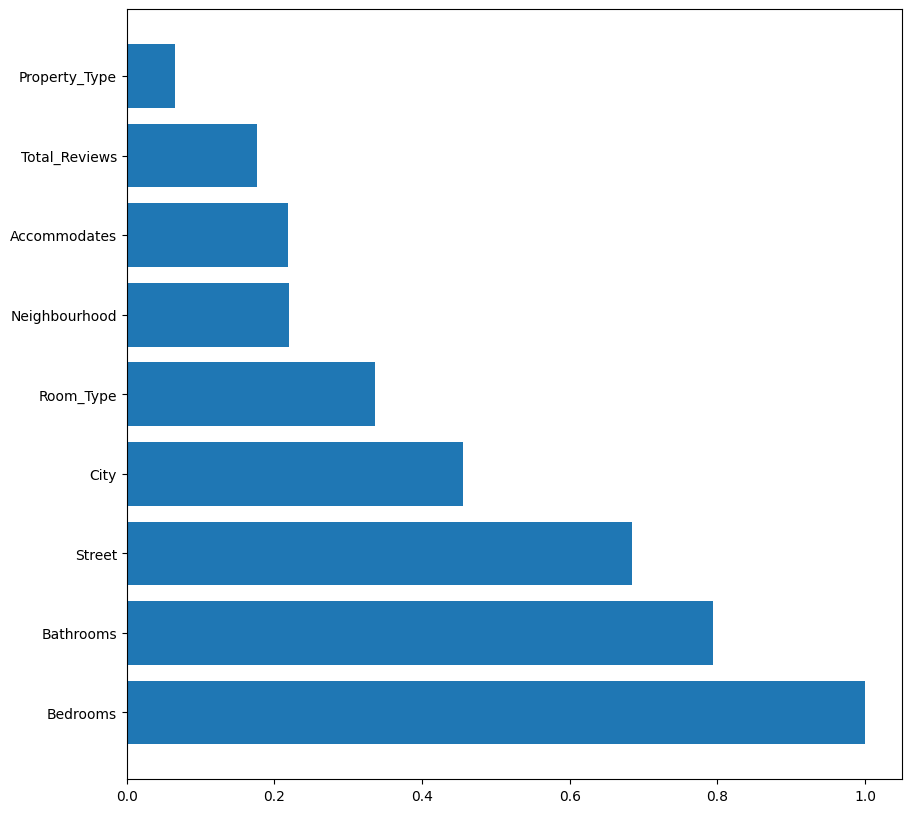

In [80]:
importances = np.mean([tree.feature_importances_ for tree in baggingRegressor.estimators_], axis=0)
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),feature_names[indices])
plt.show()